# MCMC Sampling

## Overview

For most real models, the posterior cannot be computed analytically. Markov Chain Monte Carlo (MCMC) generates samples from the posterior by constructing a Markov chain whose stationary distribution is the target posterior.

**Key algorithms:**

| Algorithm | Idea | When to use |
|---|---|---|
| Metropolis-Hastings | Accept/reject proposals | Educational, simple models |
| Gibbs sampling | Sample each parameter conditionally | Conjugate full conditionals |
| NUTS (No-U-Turn Sampler) | Gradient-based HMC | Modern default (PyMC, Stan) |

**Convergence diagnostics:**
- R-hat (Gelman-Rubin): should be < 1.01 across chains
- Effective sample size (ESS): should be > 400 per parameter
- Trace plots: chains should mix well and overlap
- Divergences (NUTS): should be zero

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
# Ecological data: species richness at restored vs control sites
n_ctrl, n_rest = 30, 35
ctrl_rich = rng.normal(18.0, 5.0, n_ctrl)
rest_rich = rng.normal(21.5, 4.5, n_rest)
print(f"Control:  mean={ctrl_rich.mean():.2f}, SD={ctrl_rich.std():.2f}, n={n_ctrl}")
print(f"Restored: mean={rest_rich.mean():.2f}, SD={rest_rich.std():.2f}, n={n_rest}")

Control:  mean=18.08, SD=3.82, n=30
Restored: mean=21.87, SD=3.63, n=35


---
## Metropolis-Hastings from Scratch

In [2]:
# Estimate the mean richness for control sites using MH
# Model: y_i ~ N(mu, sigma^2), prior: mu ~ N(18, 10^2), sigma known=5
def log_posterior(mu, data, prior_mean=18.0, prior_sd=10.0, sigma=5.0):
    log_prior = stats.norm.logpdf(mu, prior_mean, prior_sd)
    log_lik   = stats.norm.logpdf(data, mu, sigma).sum()
    return log_prior + log_lik

N_SAMPLES = 10000
proposal_sd = 1.5
samples = np.zeros(N_SAMPLES)
samples[0] = 15.0  # starting value
accepted = 0
for i in range(1, N_SAMPLES):
    current  = samples[i-1]
    proposal = rng.normal(current, proposal_sd)
    log_alpha = log_posterior(proposal, ctrl_rich) - log_posterior(current, ctrl_rich)
    if np.log(rng.uniform()) < log_alpha:
        samples[i] = proposal
        accepted += 1
    else:
        samples[i] = current
burn_in = 2000
post_samples = samples[burn_in:]
print(f"Acceptance rate: {accepted/N_SAMPLES:.3f}  (target: 0.20-0.50)")
print(f"Posterior mean: {post_samples.mean():.3f}, SD: {post_samples.std():.3f}")
ci = np.percentile(post_samples, [2.5, 97.5])
print(f"95% Credible interval: [{ci[0]:.3f}, {ci[1]:.3f}]")

Acceptance rate: 0.561  (target: 0.20-0.50)
Posterior mean: 18.072, SD: 0.921
95% Credible interval: [16.265, 19.856]


---
## Trace Plot and Convergence

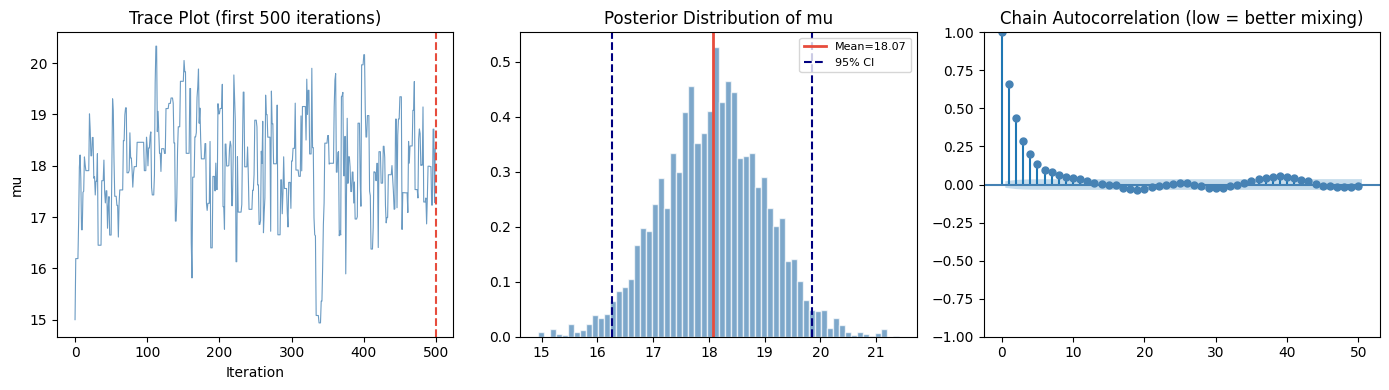

In [3]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
# Trace
axes[0].plot(samples[:500], color="steelblue", lw=0.8, alpha=0.8)
axes[0].axvline(burn_in if burn_in<500 else 500, color="#e74c3c", lw=1.5,
                linestyle="--", label="Burn-in")
axes[0].set_title("Trace Plot (first 500 iterations)")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("mu")
# Posterior histogram
axes[1].hist(post_samples, bins=60, density=True,
             color="steelblue", alpha=0.7, edgecolor="white")
axes[1].axvline(post_samples.mean(), color="#e74c3c", lw=2, label=f"Mean={post_samples.mean():.2f}")
axes[1].axvline(np.percentile(post_samples,2.5),  color="navy", lw=1.5, linestyle="--")
axes[1].axvline(np.percentile(post_samples,97.5), color="navy", lw=1.5, linestyle="--", label="95% CI")
axes[1].set_title("Posterior Distribution of mu"); axes[1].legend(fontsize=8)
# Autocorrelation of chain
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(post_samples, lags=50, ax=axes[2], color="steelblue")
axes[2].set_title("Chain Autocorrelation (low = better mixing)")
plt.tight_layout(); plt.show()

---
## PyMC: Modern MCMC with NUTS

In [4]:
try:
    import pymc as pm
    import arviz as az
    with pm.Model() as richness_model:
        # Priors
        mu_ctrl = pm.Normal("mu_ctrl", mu=18, sigma=10)
        mu_rest = pm.Normal("mu_rest", mu=18, sigma=10)
        sigma   = pm.HalfNormal("sigma", sigma=8)
        # Likelihood
        ctrl_obs = pm.Normal("ctrl_obs", mu=mu_ctrl, sigma=sigma, observed=ctrl_rich)
        rest_obs = pm.Normal("rest_obs", mu=mu_rest, sigma=sigma, observed=rest_rich)
        # Derived quantity: effect
        delta = pm.Deterministic("delta", mu_rest - mu_ctrl)
        # Sample
        trace = pm.sample(2000, tune=1000, chains=4, random_seed=42,
                          target_accept=0.9, progressbar=False)
    print(az.summary(trace, var_names=["mu_ctrl","mu_rest","delta","sigma"]))
    az.plot_trace(trace, var_names=["mu_ctrl","mu_rest","delta"])
    plt.tight_layout(); plt.show()
except ImportError:
    print("PyMC not installed: pip install pymc")
    print("PyMC uses NUTS (No-U-Turn Sampler) -- gradient-based HMC")
    print("Advantages: much faster convergence, handles complex posteriors,")  
    print("  automatic R-hat and ESS diagnostics via ArviZ")

PyMC not installed: pip install pymc
PyMC uses NUTS (No-U-Turn Sampler) -- gradient-based HMC
Advantages: much faster convergence, handles complex posteriors,
  automatic R-hat and ESS diagnostics via ArviZ


---
## Convergence Diagnostics

In [5]:
# Manual R-hat calculation on the MH samples (two pseudo-chains)
half = len(post_samples)//2
chain1 = post_samples[:half]
chain2 = post_samples[half:]
m = 2; n = half
chain_means = np.array([chain1.mean(), chain2.mean()])
grand_mean  = chain_means.mean()
B = n * chain_means.var(ddof=1)  # between-chain variance
W = np.mean([chain1.var(ddof=1), chain2.var(ddof=1)])  # within-chain variance
var_hat = (n-1)/n * W + B/n
R_hat = np.sqrt(var_hat / W)
print(f"R-hat: {R_hat:.4f}  (< 1.01 indicates convergence)")
# Effective sample size
from statsmodels.tsa.stattools import acf
acf_vals = acf(post_samples, nlags=100, fft=True)
rho_sum = 1 + 2*acf_vals[1:].sum()
ESS = len(post_samples) / rho_sum
print(f"ESS: {ESS:.0f} / {len(post_samples)} raw samples  (> 400 recommended)")
print(f"\nInterpretation: high autocorrelation reduces effective sample size")
print(f"For better ESS: tune proposal SD for ~25% acceptance rate")

R-hat: 1.0002  (< 1.01 indicates convergence)
ESS: 1864 / 8000 raw samples  (> 400 recommended)

Interpretation: high autocorrelation reduces effective sample size
For better ESS: tune proposal SD for ~25% acceptance rate


---

## Common Pitfalls

**1. Not discarding the burn-in period**  
The chain starts from an arbitrary initial value and takes some iterations to reach the posterior. Including burn-in samples in posterior summaries biases estimates toward the starting value. Always discard at least the first 10–25% of samples.

**2. Running only a single chain**  
A single chain may appear to have converged while being stuck in a local mode. R-hat requires at least 2 chains starting from different initial values. Always run ≥ 4 chains and verify R-hat < 1.01 for each parameter.

**3. Interpreting R-hat < 1.1 as sufficient**  
The traditional threshold of R-hat < 1.1 is now considered too lenient. The current recommendation (Vehtari et al. 2021) is R-hat < 1.01. Use ArviZ for computing the improved rank-normalised R-hat.

**4. Ignoring chain autocorrelation and reporting raw sample count as ESS**  
MCMC samples are autocorrelated — 4,000 raw samples may yield an ESS of only 200. Always report ESS alongside sample count and target ESS > 400 per parameter for reliable posterior quantiles.

**5. Treating MCMC failures (divergences, low ESS, high R-hat) as minor warnings**  
Divergences in NUTS indicate the sampler could not explore the posterior correctly — posterior summaries from a model with divergences are unreliable. Reparameterise, increase `target_accept`, or simplify the model before drawing conclusions.
---
*python_methods_library - Samantha McGarrigle*